In [1]:
from pathlib import Path

from jax import config
import jax.numpy as np
config.update("jax_enable_x64", True)

from gwfast.lensing_utils import compute_exact_lensed_angles

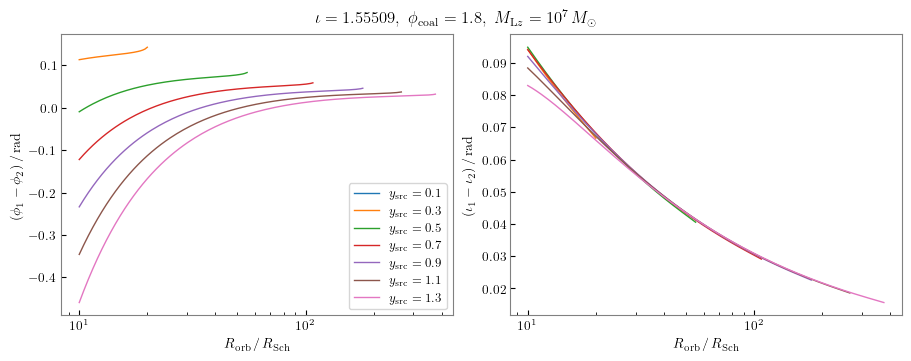

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), 
                         sharex=True, constrained_layout=True)

size = 400
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, np.pi/2 * 0.93),
    'Phicoal': np.full(size, 1.8),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}

def regulate_phi_diff(phi_diff):
    mod2pi = np.mod(phi_diff, 2*np.pi)
    return np.where(mod2pi > np.pi, mod2pi - 2 * np.pi, mod2pi)
    
for idx, y_src in enumerate(range(1, 14, 2)):
    lensing_params['src_pos'] = np.full(size, y_src*0.1)
    lensed_params = compute_exact_lensed_angles(lensing_params)
    
    axes[0].plot(r_orbits, regulate_phi_diff(lensed_params['phase_p'] - lensed_params['phase_m']), c=f'C{idx}', label=fr'$y_{{\rm src}} = {y_src*0.1:>.1f}$')
    axes[1].plot(r_orbits, lensed_params['iota_p'] - lensed_params['iota_m'], c=f'C{idx}')
    
axes[0].legend()
for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$R_{\rm orb}\,/\,R_{\rm Sch}$')
    
axes[0].set_ylabel(r'$(\phi_1 - \phi_2)\,/\,{\rm rad}$')
axes[1].set_ylabel(r'$(\iota_1 - \iota_2)\,/\,{\rm rad}$')
fig.suptitle(fr'$\iota = {np.pi/2 * 0.99:.5f},\ \phi_{{\rm coal}} = 1.8,\ M_{{{{\rm L}}z}} = 10^7\,M_\odot$')
fig.savefig('opening_angle_plot.png', dpi=300)

[7.81279511e+01 8.23421352e+01 8.67676428e+01 9.14147438e+01
 9.62942000e+01 1.01417289e+02 1.06795827e+02 1.12442196e+02
 1.18369373e+02 1.24590951e+02 1.31121177e+02 1.37974976e+02
 1.45167988e+02 1.52716599e+02 1.60637980e+02 1.68950118e+02
 1.77671863e+02 1.86822960e+02 1.96424101e+02 2.06496961e+02
 2.17064252e+02 2.28149766e+02 2.39778431e+02 2.51976363e+02
 2.64770922e+02 2.78190773e+02 2.92265944e+02 3.07027895e+02
 3.22509584e+02 3.38745538e+02 3.55771926e+02 3.73626639e+02
 3.92349374e+02 4.11981712e+02 4.32567215e+02 4.54151517e+02
 4.76782419e+02 5.00509999e+02 5.25386713e+02 5.51467512e+02
 5.78809957e+02 6.07474345e+02 6.37523839e+02 6.69024602e+02
 7.02045939e+02 7.36660449e+02 7.72944178e+02 8.10976781e+02
 8.50841698e+02 8.92626328e+02 9.36422220e+02 9.82325269e+02
 1.03043592e+03 1.08085938e+03 1.13370586e+03 1.18909080e+03
 1.24713509e+03 1.30796538e+03 1.37171433e+03 1.43852088e+03
 1.50853056e+03 1.58189581e+03 1.65877627e+03 1.73933920e+03
 1.82375974e+03 1.912221

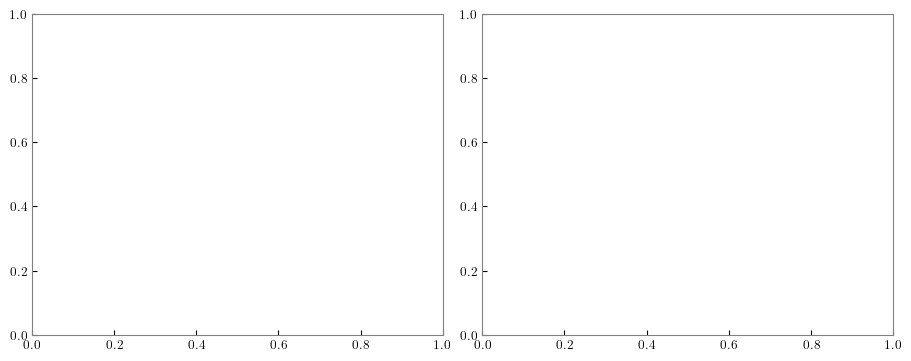

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), 
                         sharex=True, constrained_layout=True)

size = 400
r_orbits = np.geomspace(10, 100_000, size)
lensing_params = {
    'iota': np.full(size, np.pi/2 * 0.93),
    'Phicoal': np.full(size, 1.8),
    'R_orbit': r_orbits,
    'dL': np.full(size, 1.0),  # Gpc
    'M_lz': np.full(size, 1e7),
    'src_pos': np.full(size, .9),
}

lensed_params = compute_exact_lensed_angles(lensing_params)